In [ ]:
!pip install -q -U "trl>=0.19.0" torch transformers peft accelerate bitsandbytes trl datasets tqdm trl
import torch
torch.set_default_dtype(torch.float16)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 171.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 57.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from huggingface_hub import notebook_login
notebook_login()

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Loading and classification

In [ ]:
import pandas as pd
import ast

#Extract lists from strings
converters_dict = {'content': ast.literal_eval, 'type': ast.literal_eval}

# Define new path corresponding to onde drive path.
path = "/content/drive/MyDrive/GDS_group_project_main/Group_project/validation_set.csv"
df = pd.read_csv(path, converters=converters_dict,
                 usecols=['content', 'type'])

fake_news = ['fake', 'satire', 'bias', 'conspiraci', 'junksci', 'hate', 'rumor']
reliable_news = ['clickbait', 'unreliable', 'polit', 'reliabl']

def filter_type(type_list, fake, rel):
    t = type_list[0] if isinstance(type_list, list) else type_list
    if t in fake: return "fake"
    if t in rel: return "reliable"
    return "unknown"

#Join content which is a bag of words to raw content(complete sentences not seperated by comma)
df['raw_content'] = df['content'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
df['label'] = df['type'].apply(lambda x: filter_type(x, fake_news, reliable_news))

#remove type 'unknown'
df = df[df['label'] != 'unknown'].copy()


In [ ]:
df = df[df['label'] != 'unknown'].copy()

# 2. Tjek balancen nu
print("Distribution after removing 'unknown'")
print(df['label'].value_counts())


Distribution after removing 'unknown'
label
reliable    44019
fake        41533
Name: count, dtype: int64


In [ ]:
df.to_csv('/content/drive/MyDrive/GDS_group_project_main/Group_project/cleaned_data.csv', index=False)

# Data formatting for llama3

In [ ]:
from datasets import Dataset

# 1. Split det oprindelige Pandas dataframe (df) i Train og Test
full_dataset = Dataset.from_pandas(df)
split_dataset = full_dataset.train_test_split(test_size=0.1, seed=42)

train_ds_raw = split_dataset['train']
test_ds_raw = split_dataset['test']

# 2. Funktionen der bygger den korrekte Llama 3 struktur
def format_for_trl(example):
    # 1. Forbered teksten
    words = str(example['raw_content']).split()
    truncated_article = " ".join(words[:250])

    # 2. Lav prompten (Llama 3 format)
    prompt = (
        f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
        f"You are a fact-checker. Classify the following article as either 'fake' or 'reliable'. Reply ONLY with one of these two words.<|eot_id|>"
        f"<|start_header_id|>user<|end_header_id|>\n\n"
        f"Article: {truncated_article}<|eot_id|>\n"
        f"<|start_header_id|>assistant<|end_header_id|>\n\n"
    )

    # 3. Definer svaret
    answer = str(example['label'])
    completion = f"{answer}<|eot_id|>"

    # RETURNÉR ALLE NØGLER - Dette fjerner KeyError i træneren
    return {
        "text": prompt + completion,   # Bruges når packing=True
        "prompt": prompt,              # Bruges af trænerens interne validering
        "completion": completion,      # FIX: Her er nøglen træneren leder efter!
        "label": answer                # Bruges til din F1-score evaluering
    }

# Kør mapping igen for at opdatere datasættet i hukommelsen
train_ds = train_ds_raw.map(format_for_trl, remove_columns=train_ds_raw.column_names)
test_ds = test_ds_raw.map(format_for_trl, remove_columns=test_ds_raw.column_names)

Map:   0%|          | 0/76996 [00:00<?, ? examples/s]

Map:   0%|          | 0/8556 [00:00<?, ? examples/s]

# Setup of llama 3

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

# 1. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

# 2. Load Base Model (Nu med Flash Attention 2!)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# BEMÆRK: Vi har fjernet prepare_model_for_kbit_training helt!

# 3. LoRA adapter
peft_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

# 4. Anvend LoRA
model = get_peft_model(model, peft_config)

model.print_trainable_parameters()
print("Model indlæst korrekt i 16-bit med Flash Attention 2!")

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

trainable params: 83,886,080 || all params: 8,114,147,328 || trainable%: 1.0338
Model indlæst korrekt i 16-bit med Flash Attention 2!


# Setup of training for our model

In [9]:
from trl import SFTTrainer, SFTConfig

args = SFTConfig(
    output_dir="./llama3_h100_results",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=1,
    gradient_checkpointing=True,
    max_length=512,
    learning_rate=1e-4,
    bf16=True,
    tf32=True,
    optim="adamw_torch_fused",
    packing=True,
    dataset_text_field="text",
    logging_steps=50,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    args=args,
)

print("Starter træning på", len(train_ds), "artikler...")
trainer.train()

Adding EOS to train dataset:   0%|          | 0/76996 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/76996 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/76996 [00:00<?, ? examples/s]

Starter træning på 76996 artikler...


Step,Training Loss
50,0.297187
100,0.121875
150,0.105000
200,0.098359
250,0.093750
300,0.092422
350,0.081328
400,0.086563
450,0.083672
500,0.076953


Step,Training Loss
50,0.297187
100,0.121875
150,0.105000
200,0.098359
250,0.093750
300,0.092422
350,0.081328
400,0.086563
450,0.083672
500,0.076953


TrainOutput(global_step=1480, training_loss=0.0795166015625, metrics={'train_runtime': 9605.5781, 'train_samples_per_second': 4.929, 'train_steps_per_second': 0.154, 'total_flos': 9.798585475211182e+17, 'train_loss': 0.0795166015625})

Evaluerer på 1000 UNIKKE test-artikler...


  0%|          | 0/1000 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  0%|          | 4/1000 [00:00<02:40,  6.21it/s]Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  1%|          | 7/100


         MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

        fake       0.95      0.94      0.95       461
    reliable       0.95      0.96      0.95       539

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

Total Macro F1-score: 0.9497


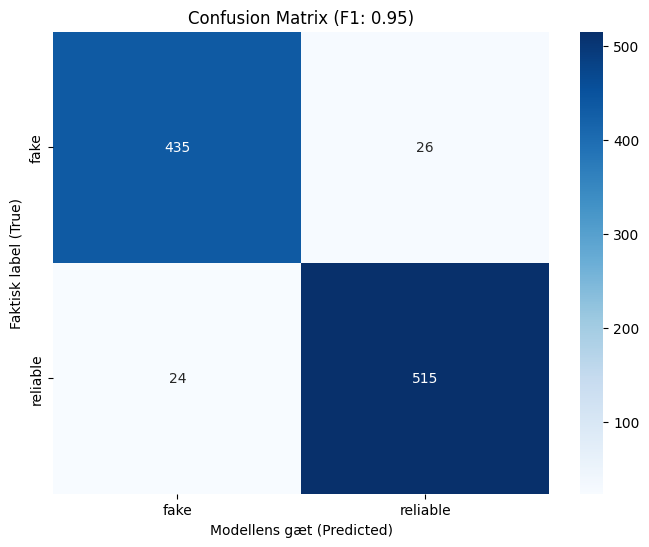

In [10]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

def evaluate_with_metrics(model, tokenizer, dataset, num_samples=1000):
    model.eval()
    predictions = []
    references = []

    # Tag et tilfældigt udsnit af TEST-dataet (Artikler modellen ALDRIG har set)
    test_subset = dataset.shuffle(seed=42).select(range(min(num_samples, len(dataset))))

    print(f"Evaluerer på {len(test_subset)} UNIKKE test-artikler...")

    for example in tqdm(test_subset):
        prompt = example['prompt']
        true_label = example['label'].lower()

        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_tokens = model.generate(
                **inputs,
                max_new_tokens=5,
                pad_token_id=tokenizer.eos_token_id,
                do_sample=False
            )

        # Dekod HELE teksten (prompt + nyt svar)
        generated_text = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

        # Det nye svar ligger altid lige efter assistent-headeren
        # Hvis vi ikke kan finde headeren, falder vi tilbage på gammel metode
        try:
            # Vi ved fra formateringen at assistant header slutter med \n\n
            prediction = generated_text.split("assistant\n\n")[-1].strip().lower()
        except:
            prediction = generated_text.replace(prompt, "").strip().lower()

        # Mapping (Samme som før)
        if "reliable" in prediction:
            pred_clean = "reliable"
        elif "fake" in prediction:
            pred_clean = "fake"
        else:
            pred_clean = "unknown"

        predictions.append(pred_clean)
        references.append(true_label)

    # ... [Resten af din udskrifts- og heatmap-kode fra din forrige besked forbliver uændret her] ...

    print("\n" + "="*40)
    print("         MODEL PERFORMANCE REPORT")
    print("="*40)
    print(classification_report(references, predictions))

    macro_f1 = f1_score(references, predictions, average='macro')
    print(f"Total Macro F1-score: {macro_f1:.4f}")

    labels = ["fake", "reliable"]
    cm = confusion_matrix(references, predictions, labels=labels)
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (F1: {macro_f1:.2f})')
    plt.ylabel('Faktisk label (True)')
    plt.xlabel('Modellens gæt (Predicted)')
    plt.show()

# VIGTIGT: Vi kører nu på TEST_DS
evaluate_with_metrics(model, tokenizer, test_ds, num_samples=1000)